Biometrich Technologies and Behavioural Security
# **<center>Tutorial -  CNN Keras Facial Expression Recognition</center>**

In [ ]:
#@title Step 1: Load Data and packages
import matplotlib.pyplot as plt
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import os
import dlib
import time
from skimage import feature
from IPython.display import HTML, display
from IPython.display import clear_output

#Function for progress bar.
def progress(value, max=100):
    return HTML("""<progress value='{value}' max='{max}', style='width: 100%'>
            {value}
        </progress>""".format(value=value, max=max))

from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

#downloaded = drive.CreateFile({'id': '1nWbItUzADjC3OtN3ijph6S5PIMTYfT2H'})   # replace the id with id of file you want to access
downloaded = drive.CreateFile({'id': '1pq7wiPImgPMaCszC5dvdLx5tq-cUoe_W'})
downloaded.GetContentFile('jaffedbase.zip')        # replace the file name with your file
!unzip jaffedbase
clear_output()
print('Done! Press the Refresh button if files are not visible.')

Done! Press the Refresh button if files are not visible.


In [ ]:
#@title Step 2: Create data and label structures
path = "/content/jaffedbase/"
images = os.listdir(path)

print('Extracting faces...')
out = display(progress(0, len(images)*2), display_id=True)
kk=0
t = time.time()
data = []
labels = []


for j in images:
    if 'tiff' in j:
      img = cv2.imread(path+"/"+j)
      data.append(img)
      if 'HA' in j:
        labels.append(0)
      elif 'AN' in j:
        labels.append(1)
      elif 'SA' in j:
        labels.append(2)
      elif 'DI' in j:
        labels.append(3)
      elif 'FE' in j:
        labels.append(4)
      elif 'SU' in j:
        labels.append(5)
      elif 'NE' in j:
        labels.append(6)
    kk=kk+1
    out.update(progress(kk, len(images)))

elapsed = 'Process completed! Elapsed time: %.2f s' %(time.time() - t)
print(elapsed)

Extracting faces...


Process completed! Elapsed time: 0.57 s


In [ ]:
X = np.array(data)
Y = np.array(labels)

In [ ]:
#@title Step 3: Split and normalize train e test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size = 0.1)
x_train,x_val,y_train,y_val = train_test_split(x_train,y_train,test_size = 0.1)

#train and test norm
x_train = x_train.astype('float32')
x_val = x_val.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_val /= 255
x_test /= 255
x_train = (x_train - 0.5) * 2
x_val = (x_val - 0.5) * 2
x_test = (x_test - 0.5) * 2

print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_val.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')


x_train shape: (171, 256, 256, 3)
171 train samples
20 train samples
22 test samples


In [ ]:
#@title Step 4: Convert class vectors to one-hot binary class matrices
import keras
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K
from keras.layers import Dense, Dropout, Flatten, Activation
from keras.models import Sequential, Model, load_model

num_classes=7
# input image dimensions
img_rows, img_cols = 256, 256

# convert class vectors to one-hot binary class matrices
print(y_test)
y_train = keras.utils.to_categorical(y_train, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
print(y_test)

[3 6 6 0 2 5 2 1 2 0 4 5 0 5 5 0 3 5 0 1 4 3]
[[0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]]


In [ ]:
input_shape = (256, 256, 3)

In [ ]:
#@title Step 5: Create CNN Architecture
model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=input_shape))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes))
model.add(Activation('softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer='Adam',
              metrics=['accuracy'])

model.fit(x_train, y_train,
          batch_size=20,
          epochs=30,
          verbose=1,
          validation_data=(x_val, y_val))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.1587 - loss: 2.5309 - val_accuracy: 0.0500 - val_loss: 1.9749
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.1667 - loss: 1.9425 - val_accuracy: 0.0500 - val_loss: 1.9512
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.1570 - loss: 1.9217 - val_accuracy: 0.1500 - val_loss: 1.9347
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.2515 - loss: 1.8939 - val_accuracy: 0.0500 - val_loss: 1.9238
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.3025 - loss: 1.7837 - val_accuracy: 0.1000 - val_loss: 1.8619
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.3396 - loss: 1.7033 - val_accuracy: 0.4000 - val_loss: 1.7201
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.3179 - loss: 1.6183 - val_accuracy: 0.2000 - val_loss: 1.6542
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.3644 - loss: 1.5396 - val_accuracy: 0.3000 - val_loss: 1.5764
Epoch 9/

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step


[Text(0.5, 68.24999999999999, 'Predicted label'),
 Text(83.24999999999999, 0.5, 'True label')]

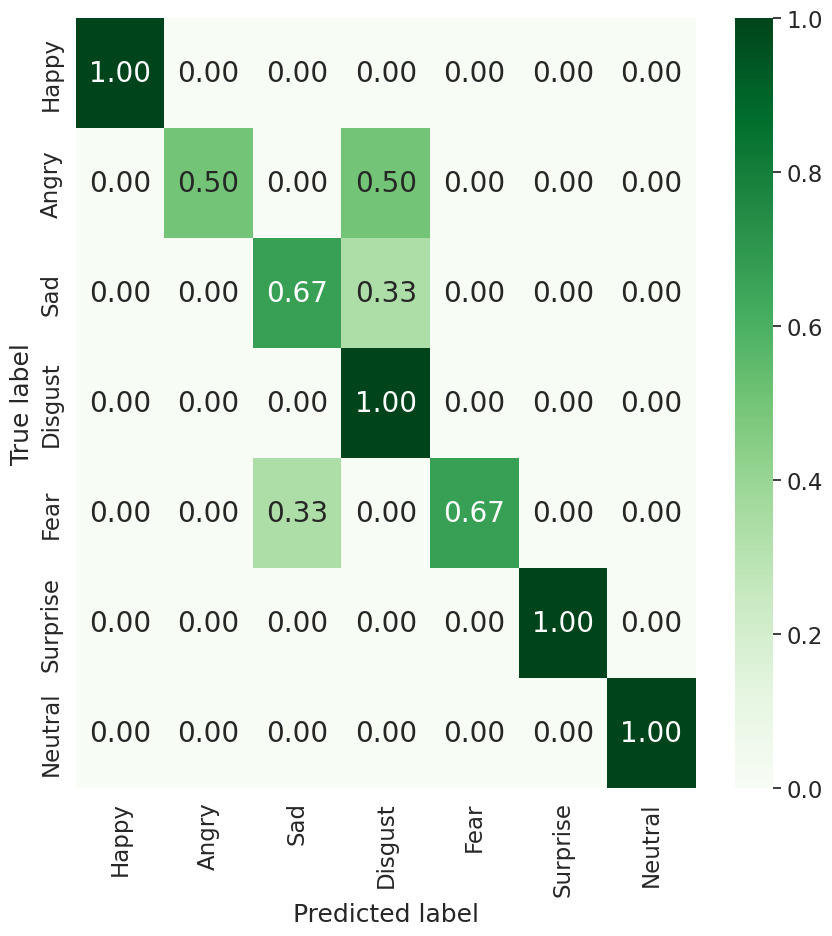

In [ ]:
#@title Step 6: Model Evaluation

y_pred = np.argmax(model.predict(x_test),axis=1)
emotion_labels = ["Happy","Angry","Sad", "Disgust", "Fear", "Surprise", "Neutral"]
y_true = np.asarray([np.argmax(i) for i in y_test])

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
cm_normalised = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.set(font_scale=1.5)
fig, ax = plt.subplots(figsize=(10,10))
ax = sns.heatmap(cm_normalised, annot=True, linewidths=0, square=False,
                    cmap="Greens", yticklabels=emotion_labels, xticklabels=emotion_labels, vmin=0, vmax=np.max(cm_normalised),
                    fmt=".2f", annot_kws={"size": 20})
ax.set(xlabel='Predicted label', ylabel='True label')

In [ ]:
score = model.evaluate(x_test, y_test)
print('Evaluation loss: ', score[0])
print('Evaluation accuracy: ', score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 844ms/step - accuracy: 0.8182 - loss: 0.5594
Evaluation loss:  0.5593718886375427
Evaluation accuracy:  0.8181818127632141
